In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = {
    'Framework': ['Baseline (HTML+CSS)', 'Tailwind CSS', 'UnoCSS (Attributify)', 'Bootstrap', 
                  'Daisy UI', 'Vanilla Extract', 'Open Props', 'Formantic UI', 'HAML', 'Pug'],
    'Lines': [114, 30, 38, 55, 29, 110, 115, 43, 105, 105],
    'Chars': [2553, 1370, 1604, 1675, 1258, 2796, 3051, 1309, 2476, 2472],
    'GPT4o_Tokens': [753, 391, 518, 486, 350, 822, 854, 375, 677, 662],
    'CodeLLM_Tokens': [802, 420, 550, 506, 366, 842, 866, 387, 724, 710],
    'Char_Token_Ratio': [3.39, 3.50, 3.10, 3.45, 3.59, 3.40, 3.57, 3.49, 3.66, 3.73],
    'Nesting_Depth': [7, 7, 7, 7, 7, 5, 7, 8, 1, 1],
    'Redundancy_Ratio': [0.7676, 0.6343, 0.6506, 0.6276, 0.5514, 0.7397, 0.7927, 0.5840, 0.7400, 0.7372],
    'Entropy': [6.1036, 6.4172, 6.5540, 6.7213, 6.5820, 6.4612, 6.1269, 6.3721, 5.9978, 5.9756]
}

df = pd.DataFrame(data)

In [3]:
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

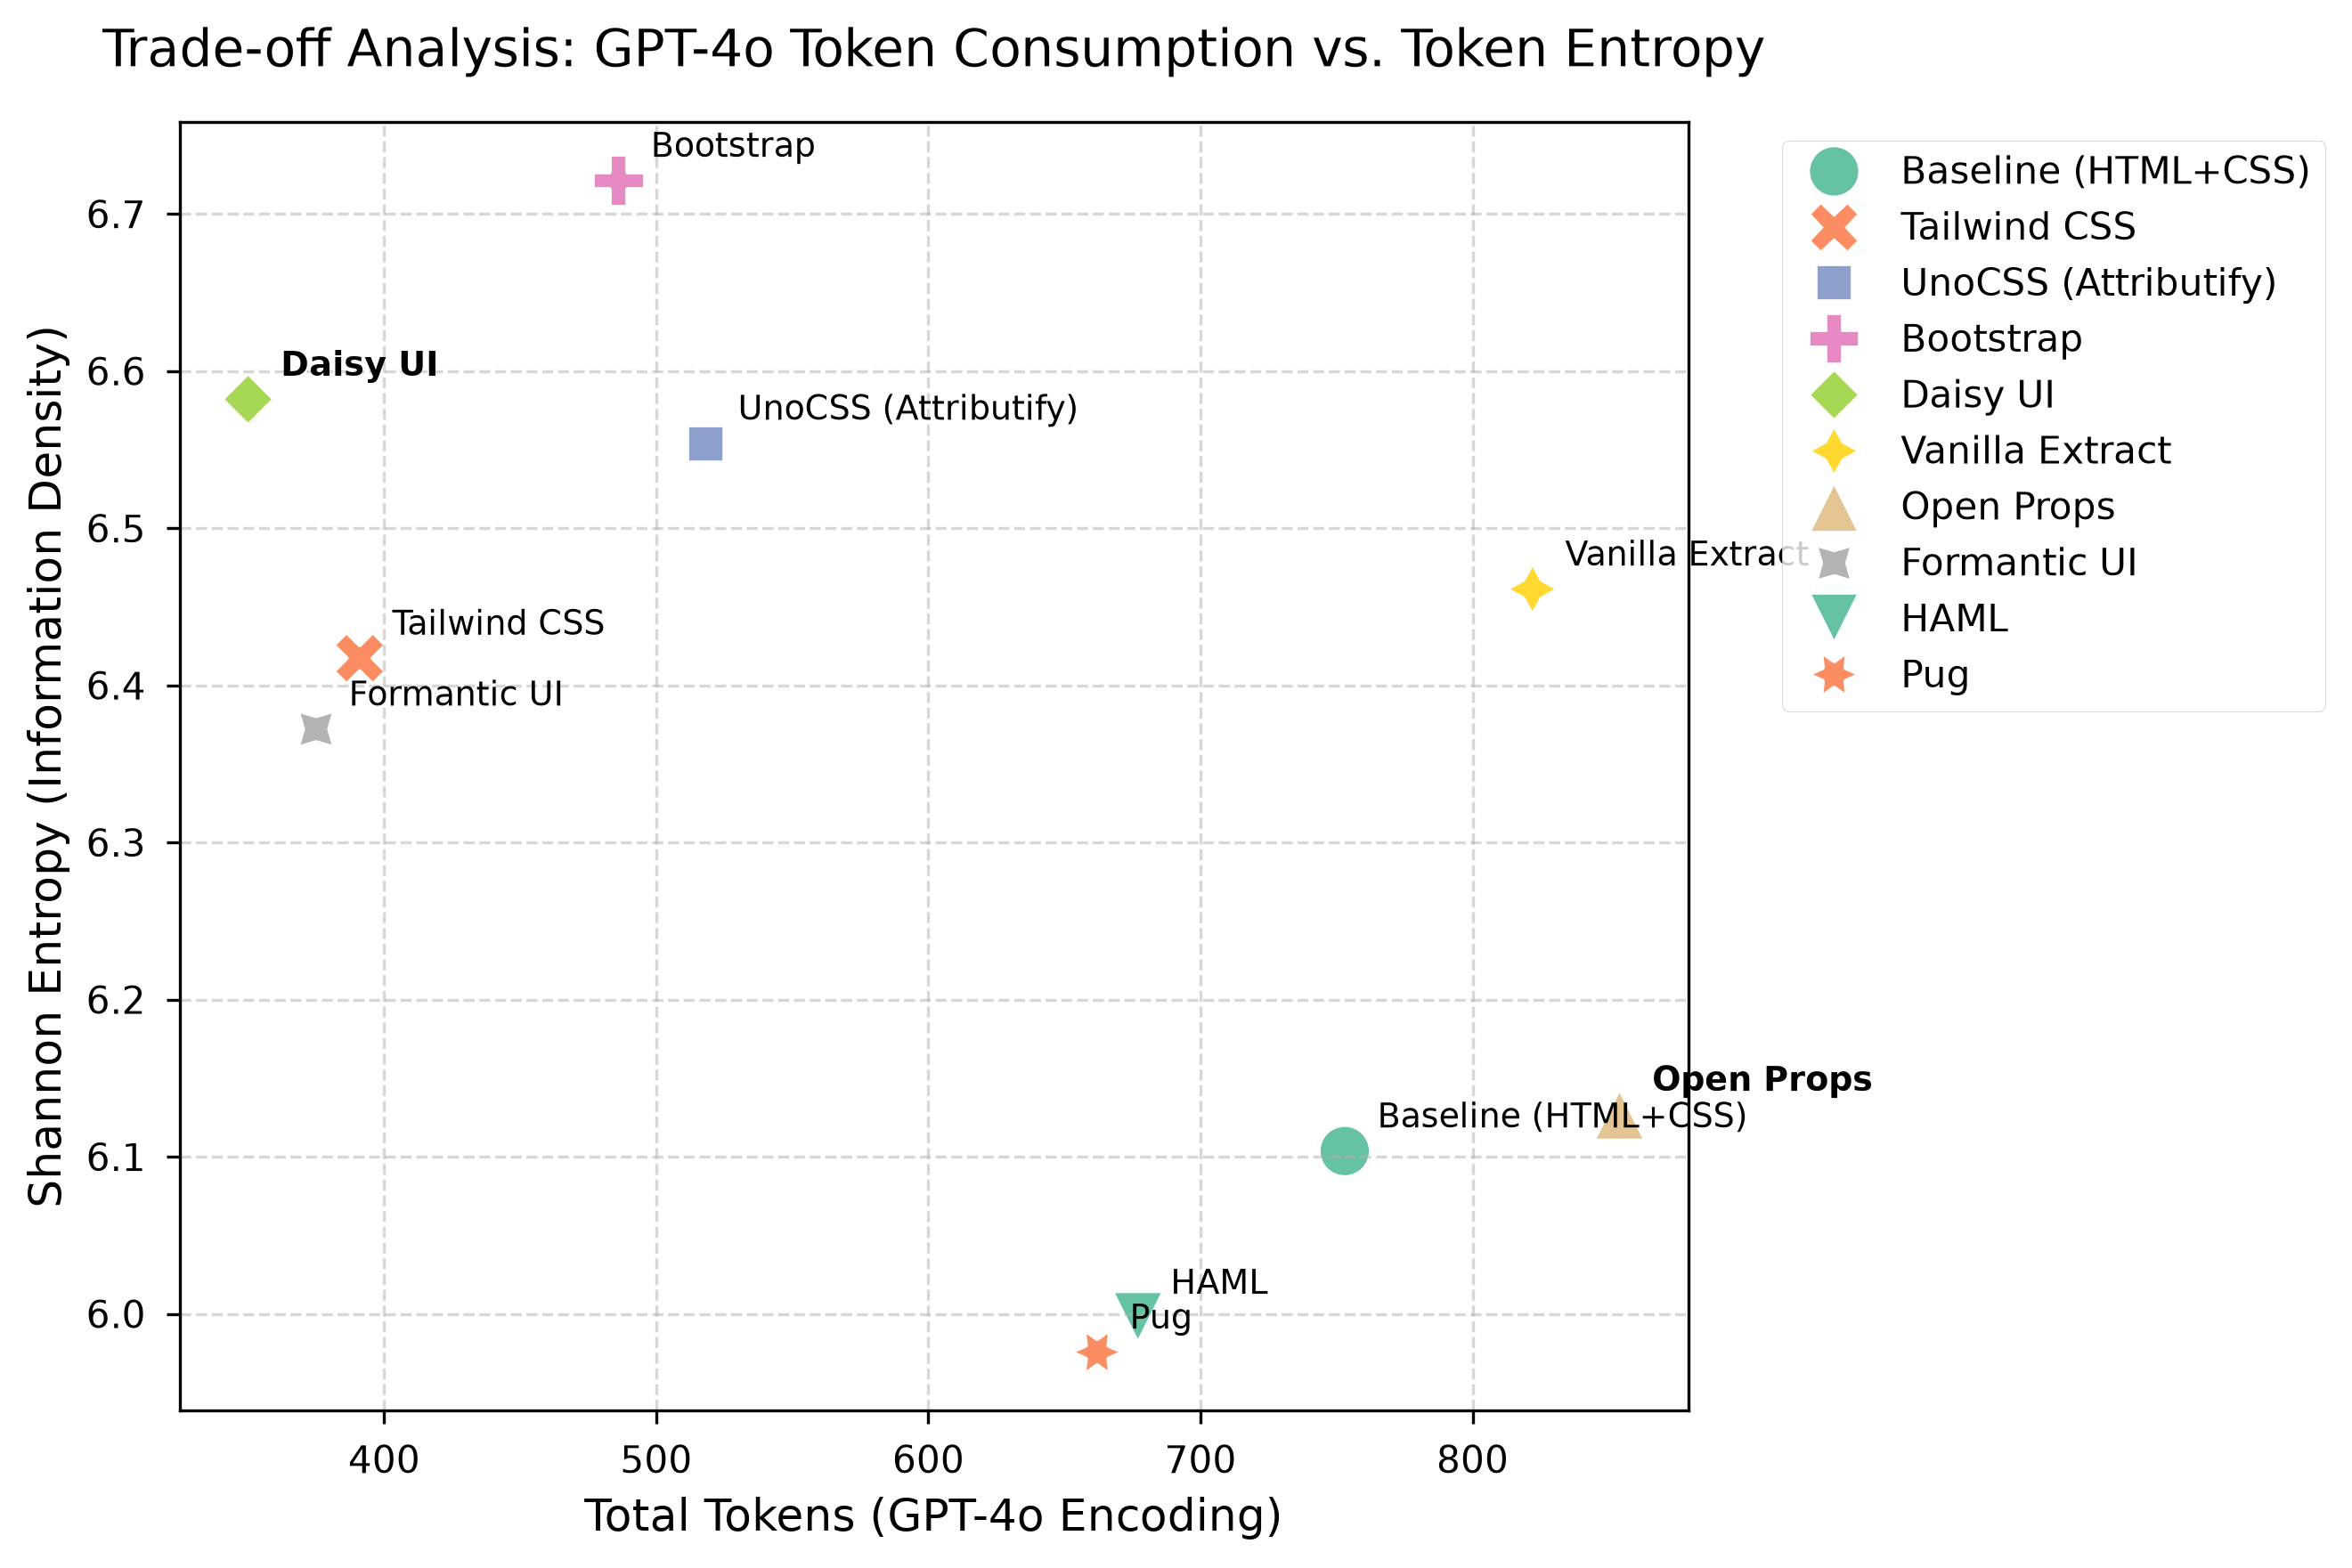

In [4]:
# ==========================================
# CHART 1: Token Count (GPT-4o) vs. Entropy (Scatter Trade-off Plot)
# ==========================================
plt.figure(figsize=(9, 6), dpi=300)
scatter = sns.scatterplot(
    data=df, 
    x='GPT4o_Tokens', 
    y='Entropy', 
    hue='Framework', 
    style='Framework', 
    s=200, 
    palette='Set2'
)

for i in range(df.shape[0]):
    plt.text(
        df.GPT4o_Tokens[i] + 12, 
        df.Entropy[i] + 0.015, 
        df.Framework[i], 
        fontsize=9, 
        weight='bold' if df.Framework[i] in ['Daisy UI', 'Open Props'] else 'normal'
    )

plt.title('Trade-off Analysis: GPT-4o Token Consumption vs. Token Entropy', pad=15)
plt.xlabel('Total Tokens (GPT-4o Encoding)')
plt.ylabel('Shannon Entropy (Information Density)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart1_token_vs_entropy.png', dpi=300)
plt.show()

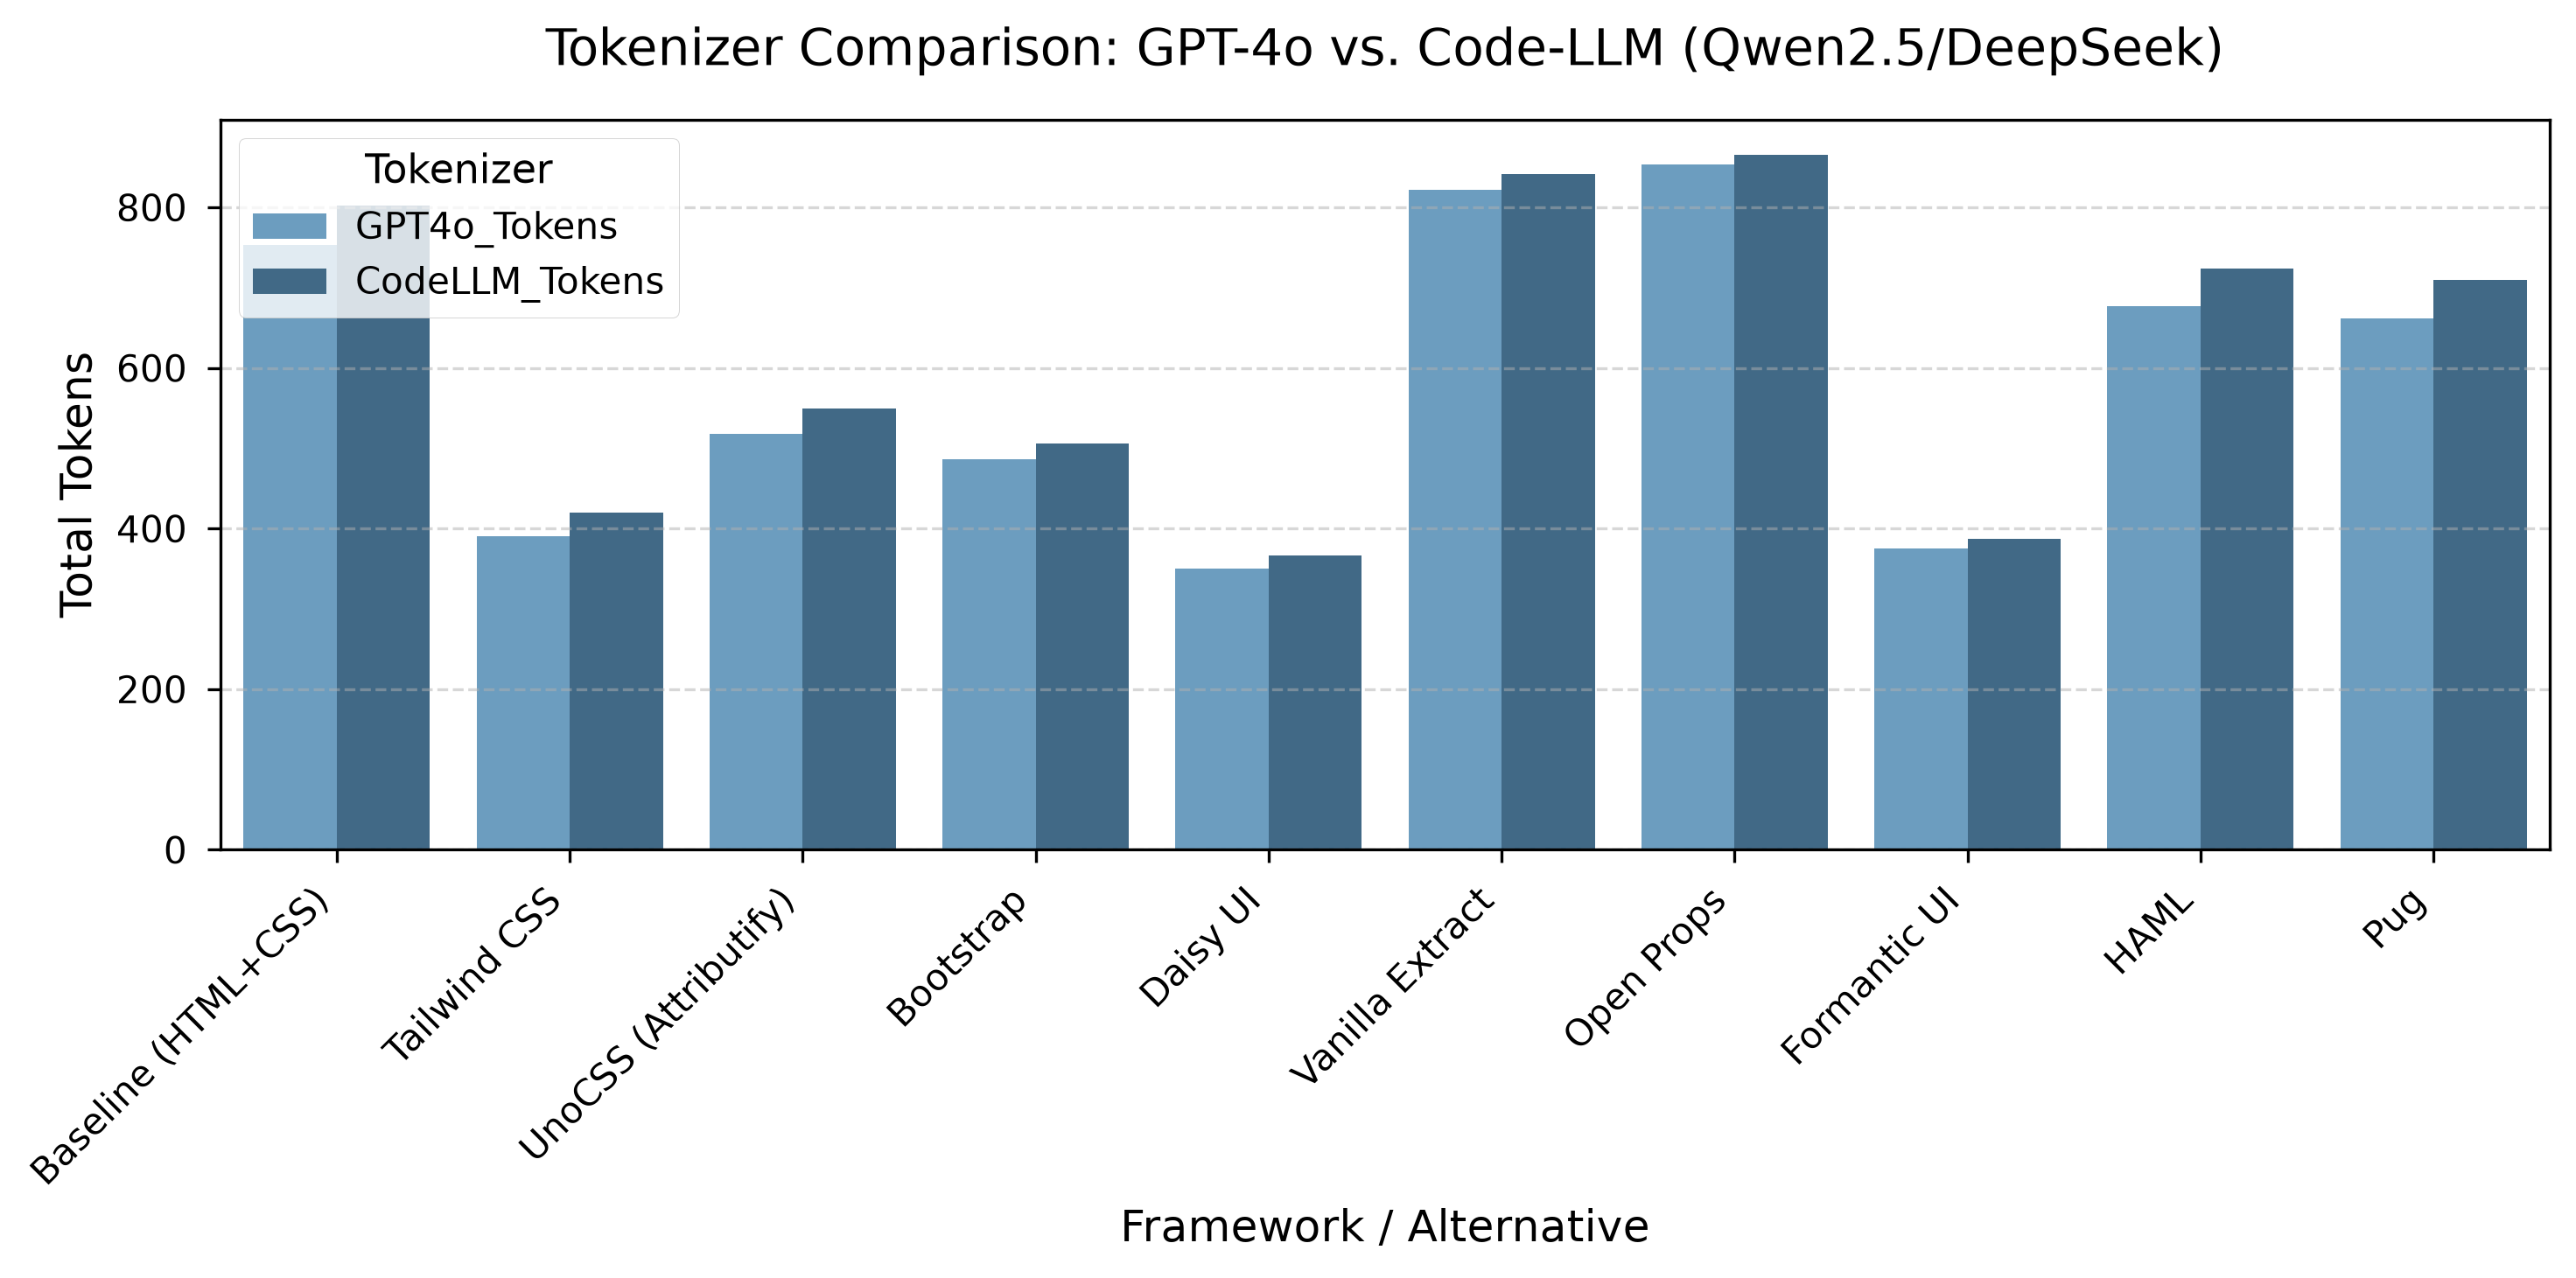

In [5]:
# ==========================================
# CHART 2: Token Overhead Across Tokenizers (Grouped Bar Chart)
# ==========================================
plt.figure(figsize=(10, 5), dpi=300)
df_melted = df.melt(id_vars=['Framework'], value_vars=['GPT4o_Tokens', 'CodeLLM_Tokens'], 
                    var_name='Tokenizer', value_name='Token Count')

sns.barplot(data=df_melted, x='Framework', y='Token Count', hue='Tokenizer', palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title('Tokenizer Comparison: GPT-4o vs. Code-LLM (Qwen2.5/DeepSeek)', pad=15)
plt.xlabel('Framework / Alternative')
plt.ylabel('Total Tokens')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart2_tokenizer_comparison.png', dpi=300)
plt.show()

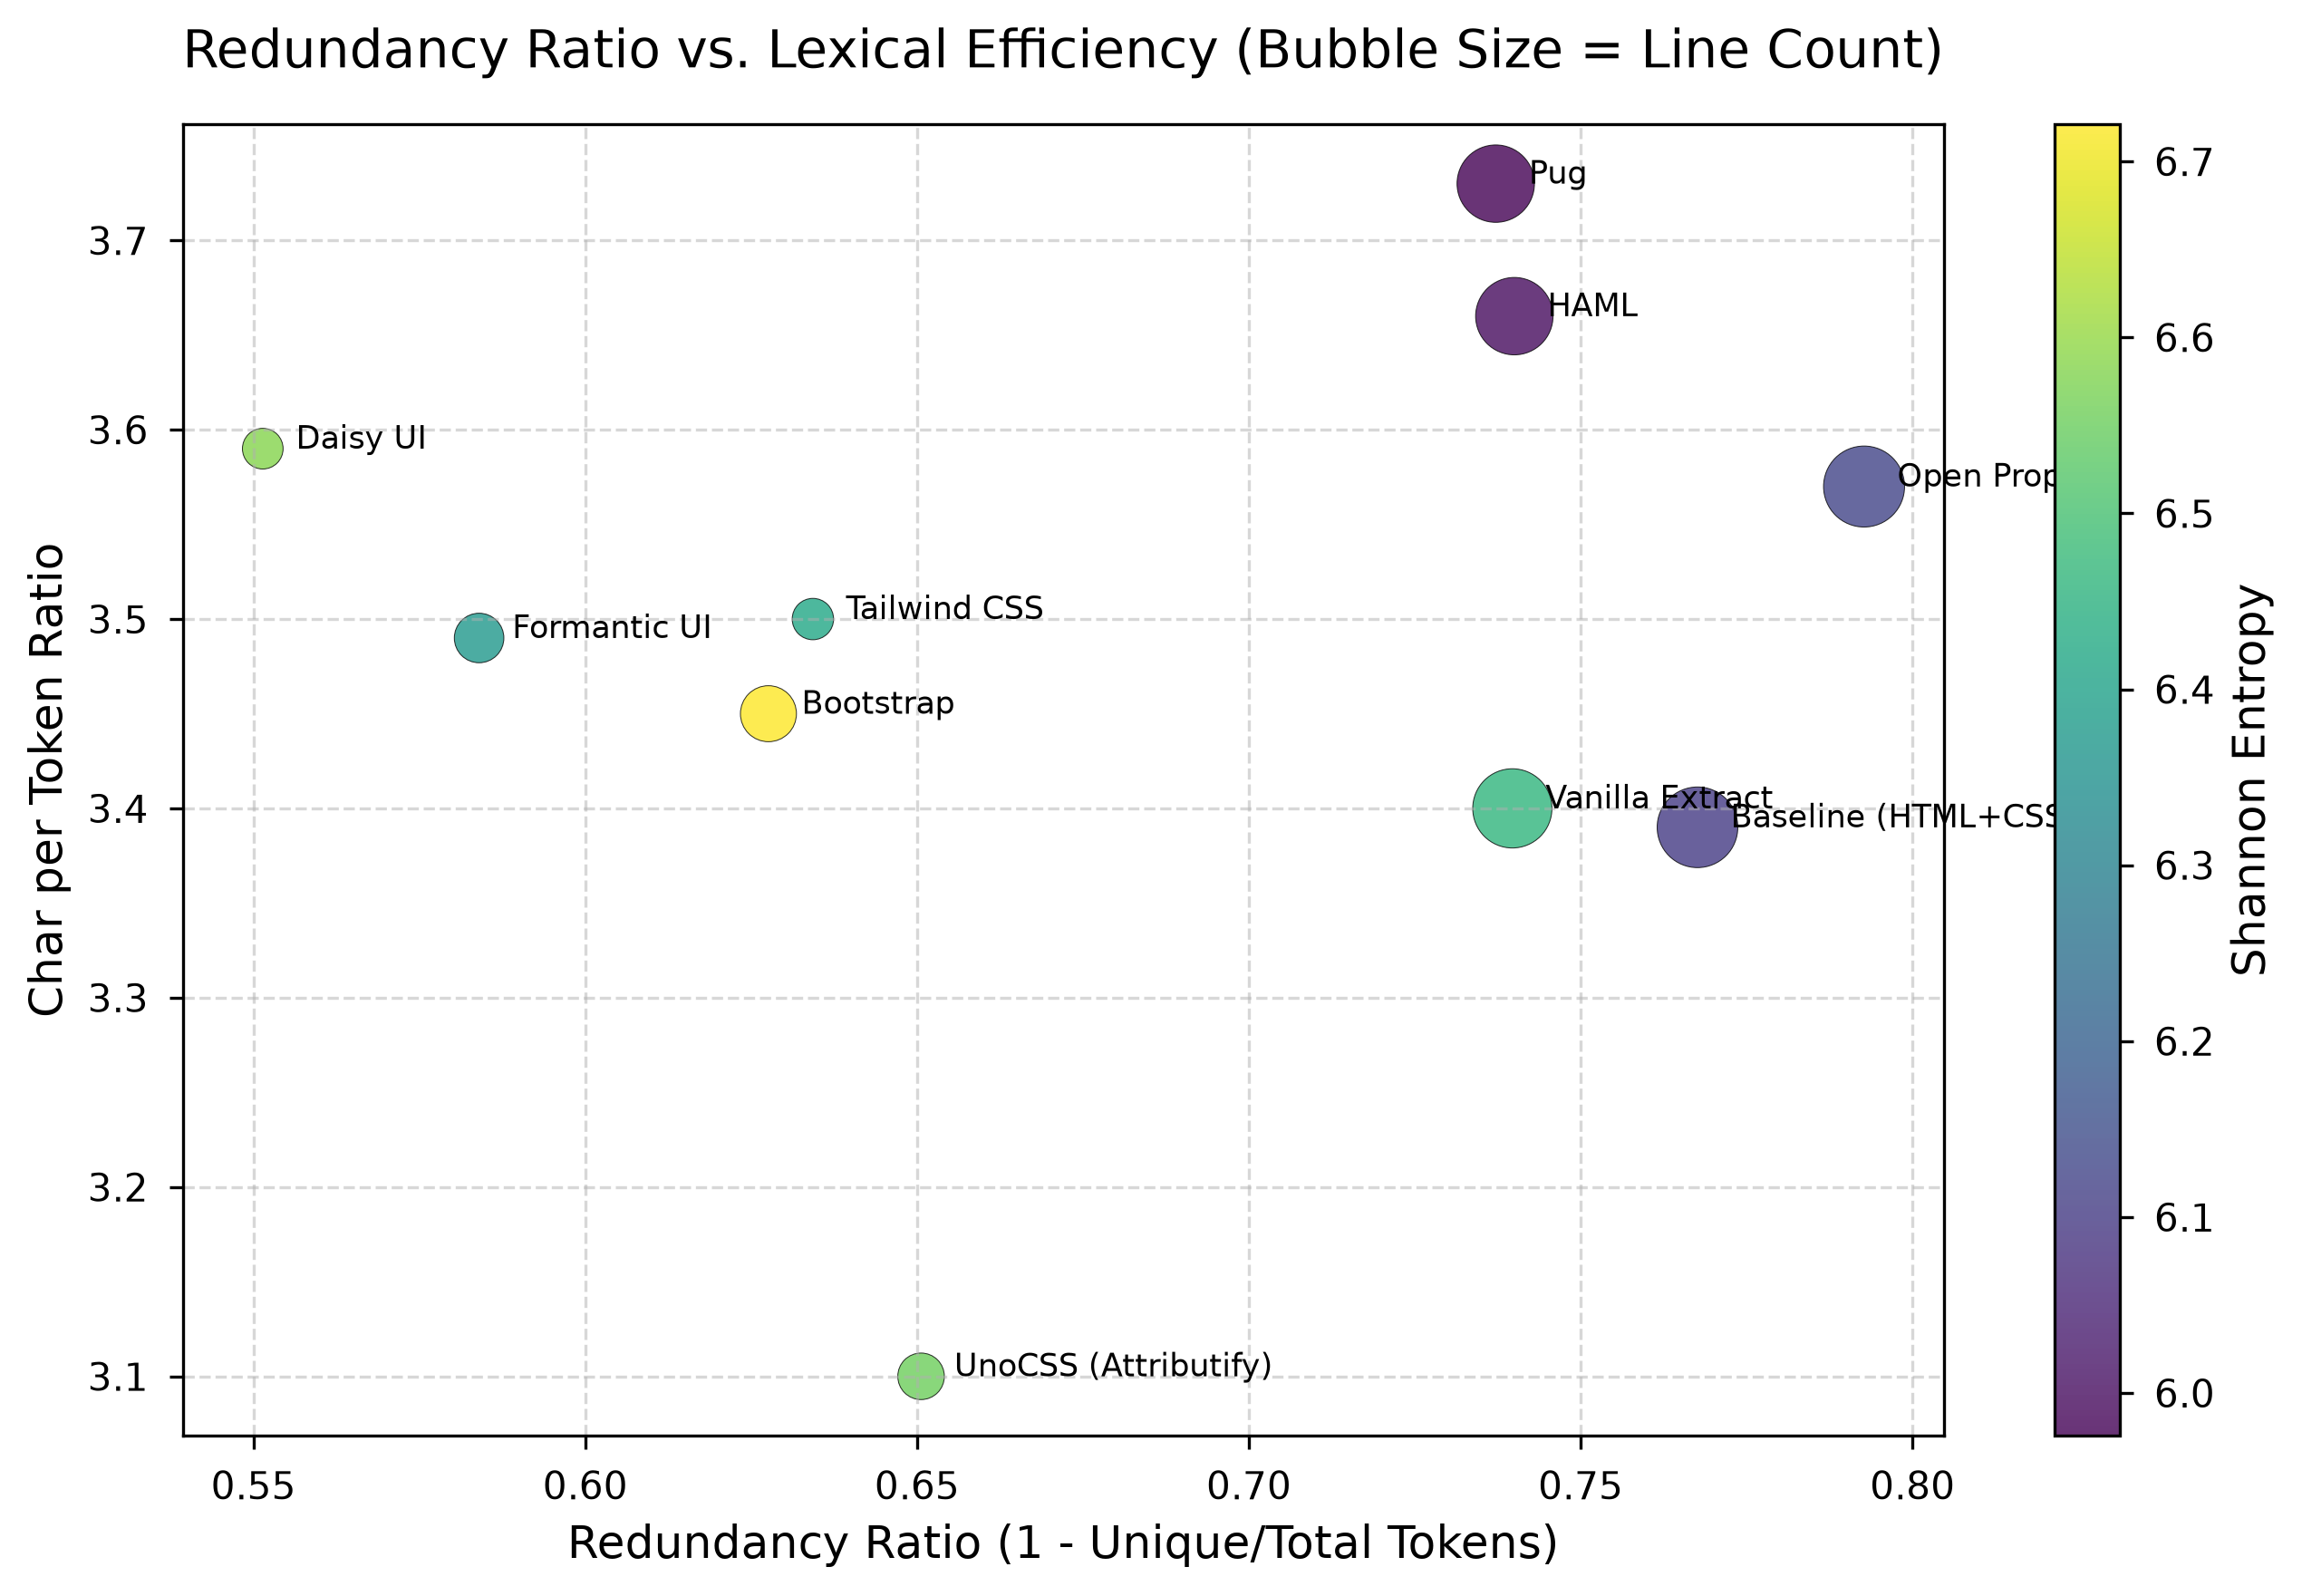

In [6]:
# ==========================================
# CHART 3: Redundancy vs. Compression Efficiency (Bubble Chart)
# ==========================================
plt.figure(figsize=(9, 6), dpi=300)
plt.scatter(
    df['Redundancy_Ratio'], 
    df['Char_Token_Ratio'], 
    s=df['Lines'] * 4,  # اندازه حباب برابر با تعداد خطوط است
    c=df['Entropy'], 
    cmap='viridis', 
    alpha=0.8, 
    edgecolors="black"
)

cbar = plt.colorbar()
cbar.set_label('Shannon Entropy')

for i in range(df.shape[0]):
    plt.text(df.Redundancy_Ratio[i] + 0.005, df.Char_Token_Ratio[i], df.Framework[i], fontsize=8.5)

plt.title('Redundancy Ratio vs. Lexical Efficiency (Bubble Size = Line Count)', pad=15)
plt.xlabel('Redundancy Ratio (1 - Unique/Total Tokens)')
plt.ylabel('Char per Token Ratio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart3_redundancy_efficiency.png', dpi=300)
plt.show()

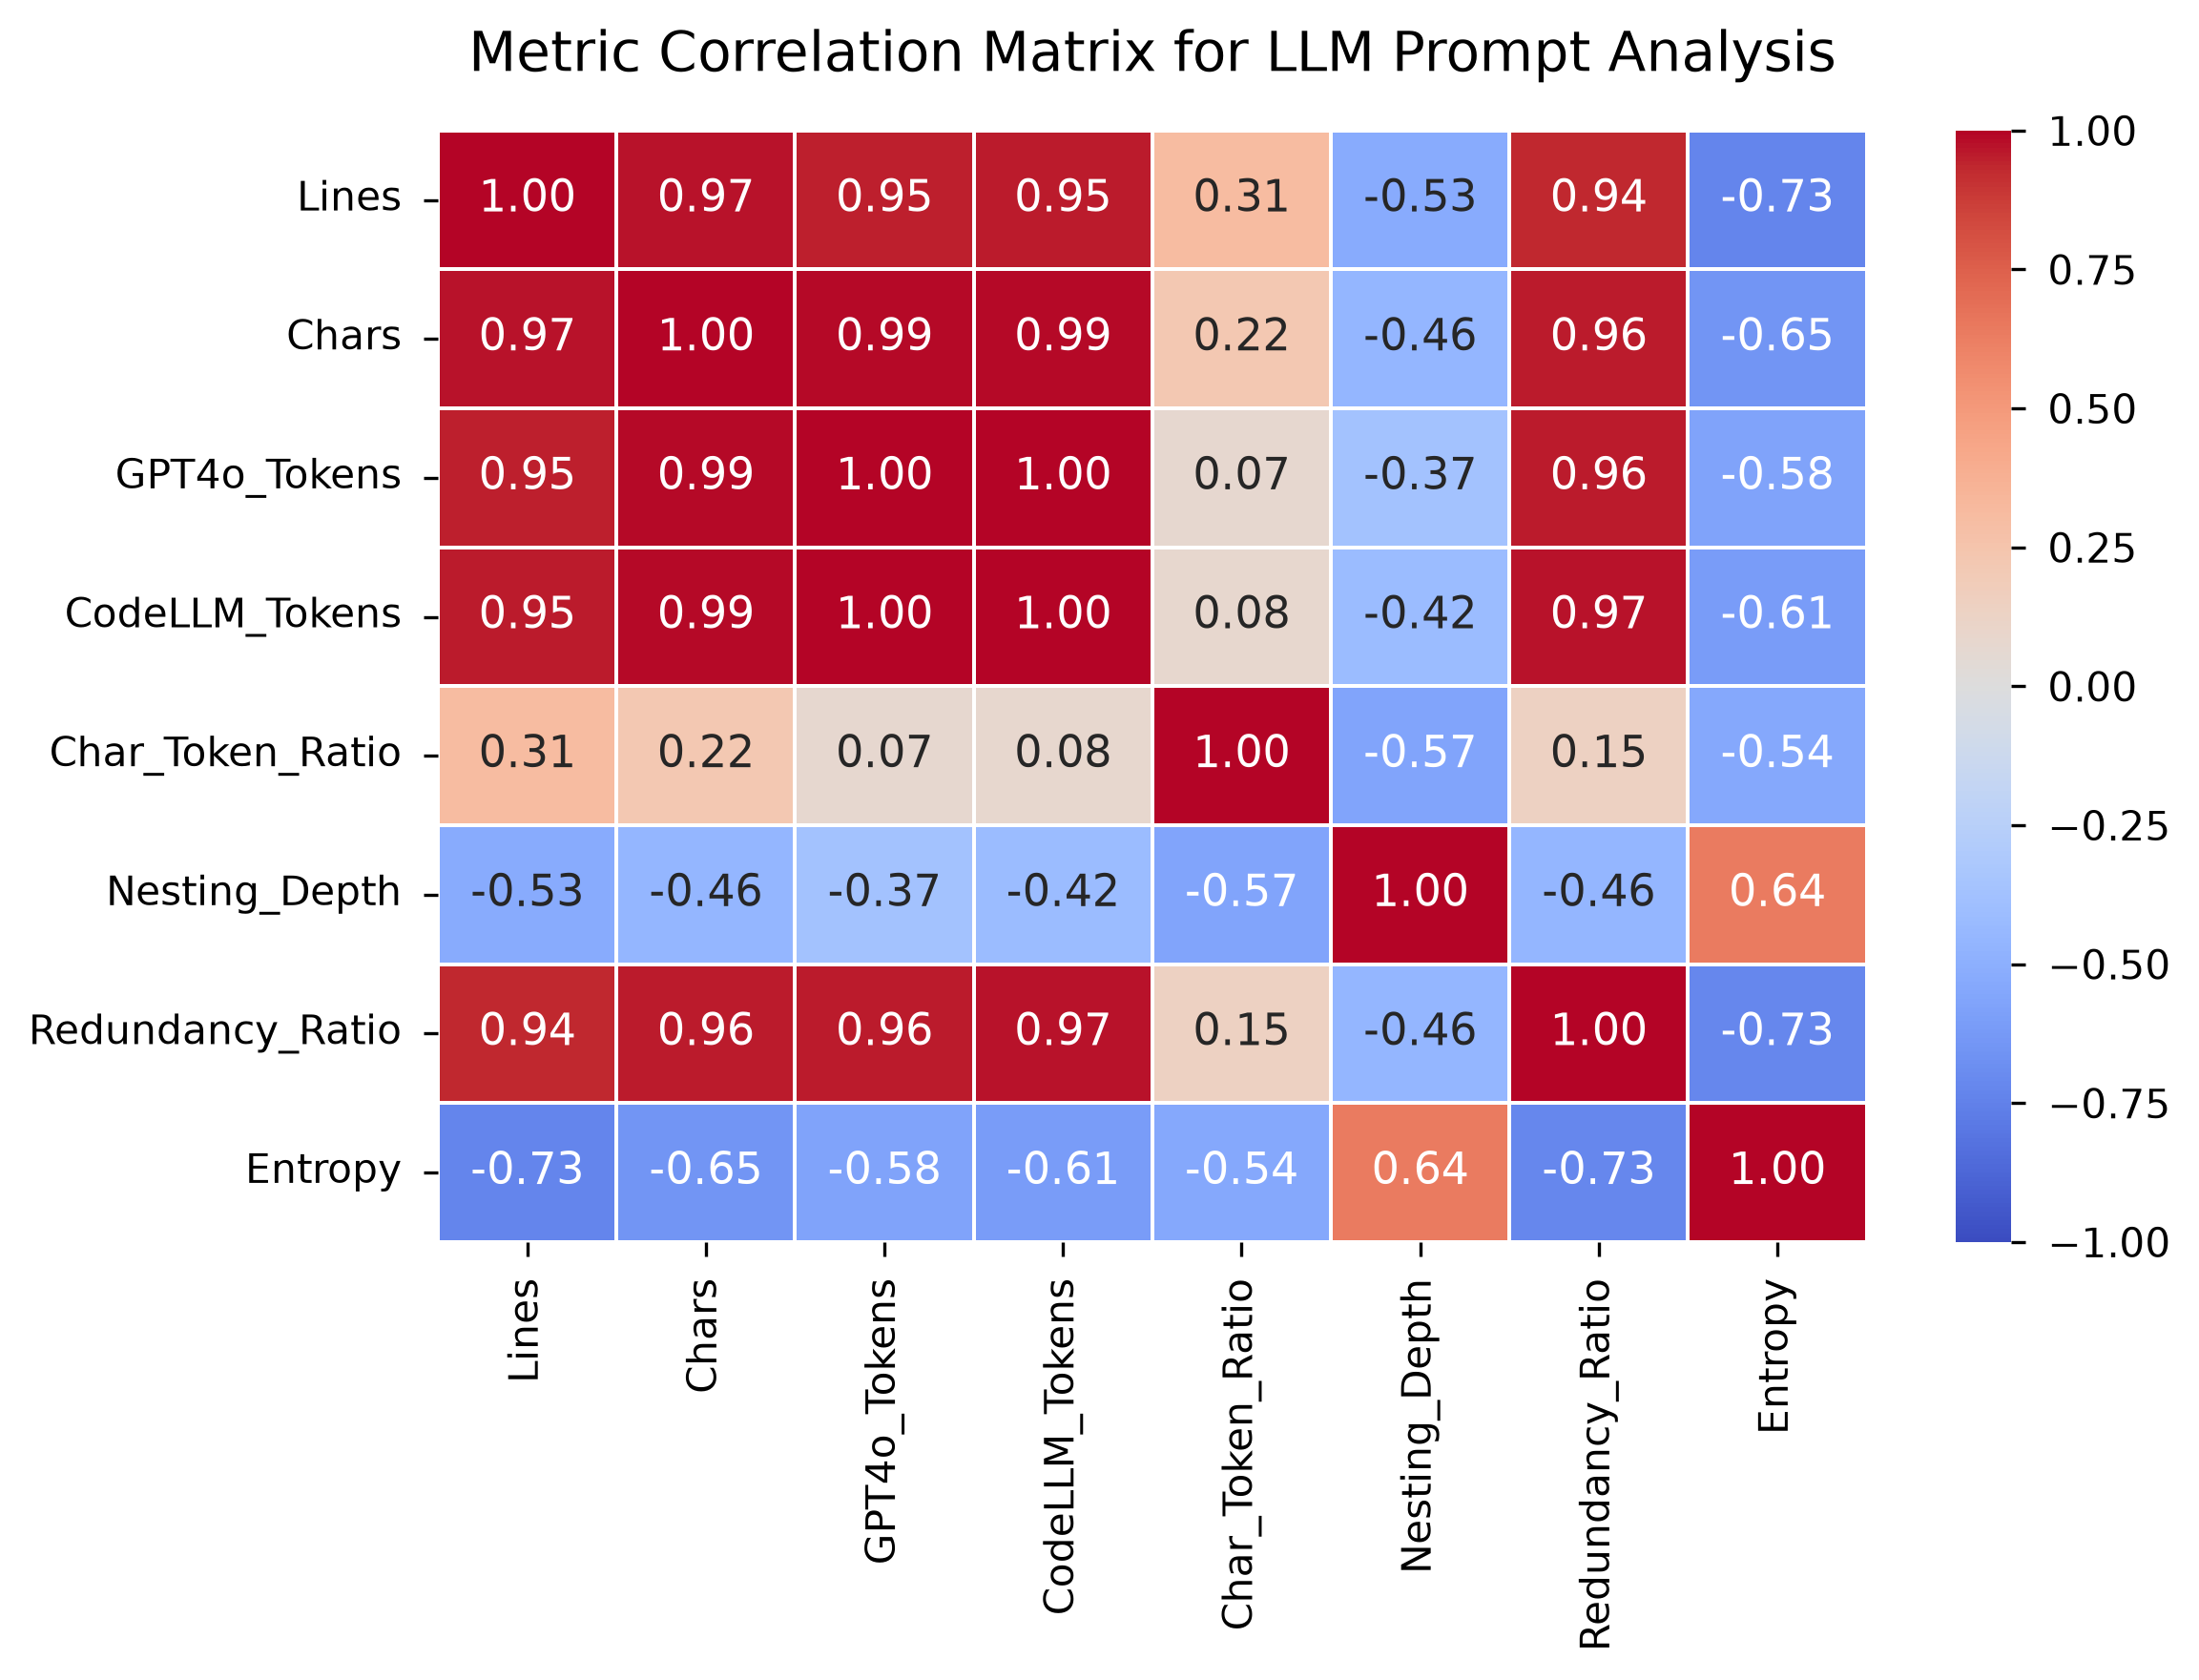

In [7]:
# ==========================================
# CHART 4: Correlation Heatmap
# ==========================================
plt.figure(figsize=(8, 6), dpi=300)
numeric_df = df.drop(columns=['Framework'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Metric Correlation Matrix for LLM Prompt Analysis', pad=15)
plt.tight_layout()
plt.savefig('chart4_correlation_heatmap.png', dpi=300)
plt.show()

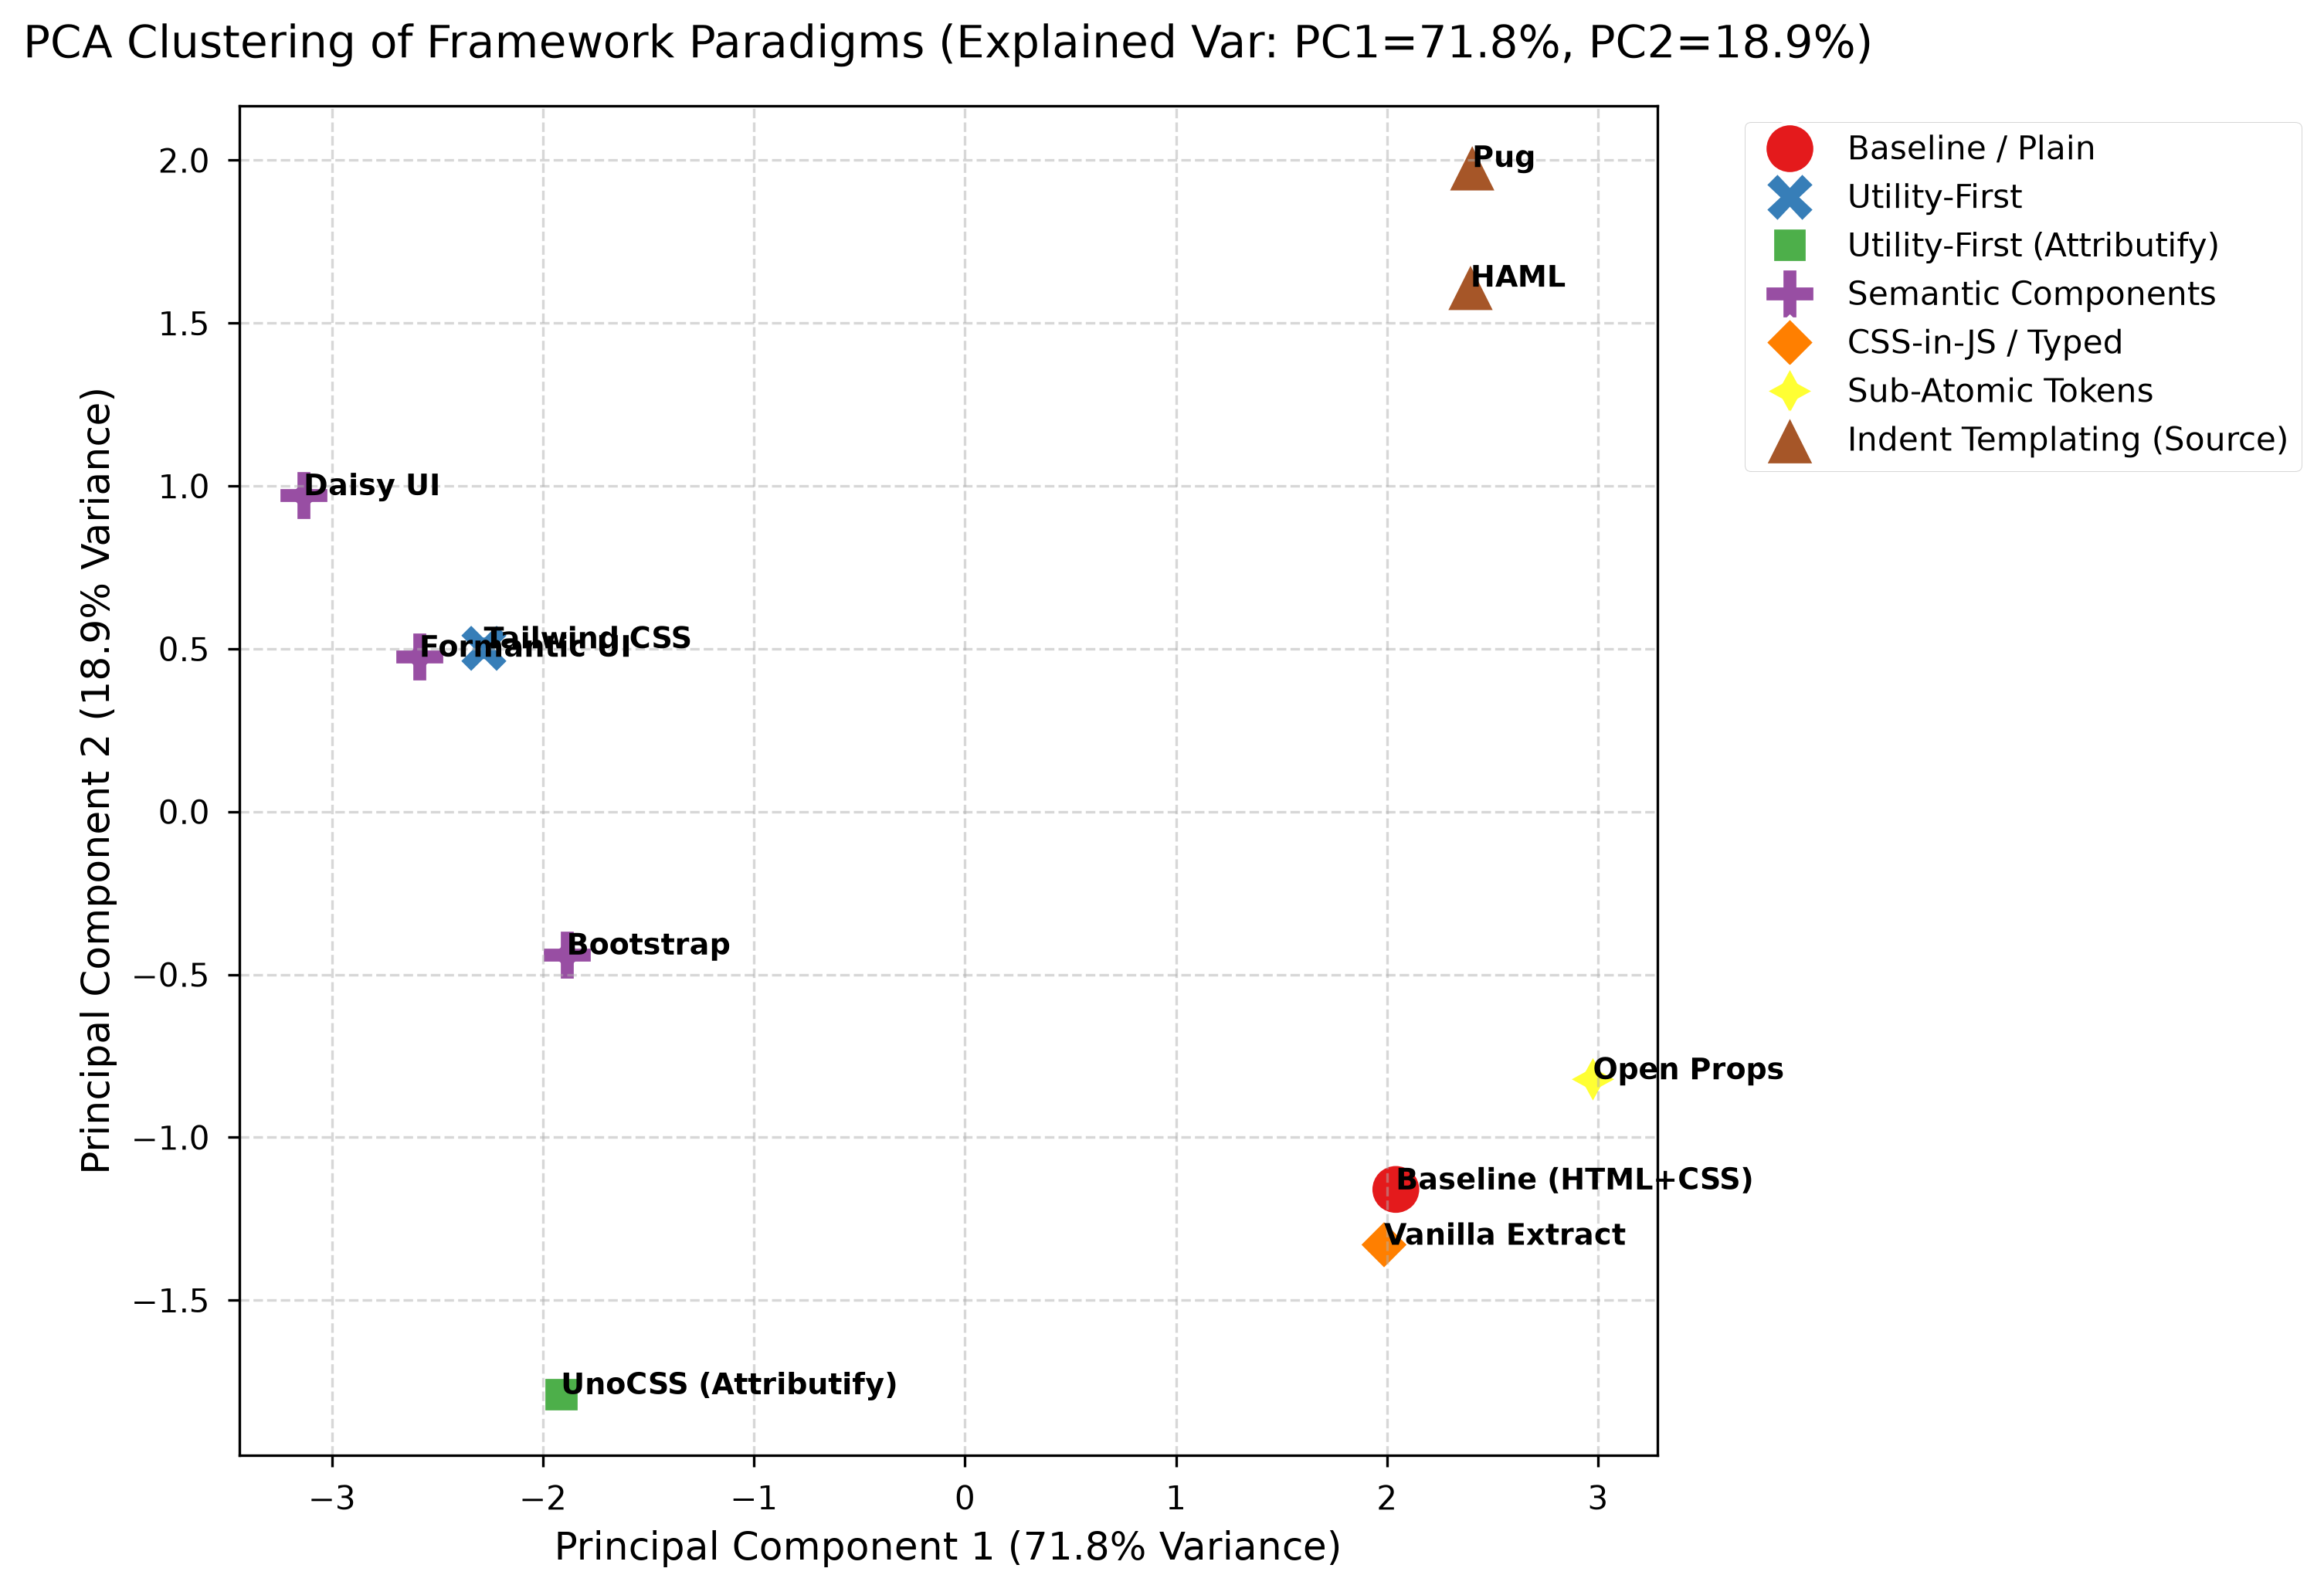

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# from adjustText import adjust_text

# ۱. آماده‌سازی ماتریس ویژگی‌ها
features = ['Lines', 'Chars', 'GPT4o_Tokens', 'CodeLLM_Tokens', 
            'Char_Token_Ratio', 'Nesting_Depth', 'Redundancy_Ratio', 'Entropy']

X = df[features].values

# ۲. استانداردسازی داده‌ها (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ۳. اعمال PCA برای کاهش ابعاد به ۲ مؤلفه اصلی
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# ۴. تعاریف دسته‌بندی پارادایم‌ها برای تحلیل PhD
paradigms = {
    'Baseline (HTML+CSS)': 'Baseline / Plain',
    'Tailwind CSS': 'Utility-First',
    'UnoCSS (Attributify)': 'Utility-First (Attributify)',
    'Bootstrap': 'Semantic Components',
    'Daisy UI': 'Semantic Components',
    'Vanilla Extract': 'CSS-in-JS / Typed',
    'Open Props': 'Sub-Atomic Tokens',
    'Formantic UI': 'Semantic Components',
    'HAML': 'Indent Templating (Source)',
    'Pug': 'Indent Templating (Source)'
}
df['Paradigm'] = df['Framework'].map(paradigms)

# ۵. رسم نمودار خوشه‌بندی PCA
plt.figure(figsize=(10, 7), dpi=300)
sns.scatterplot(
    data=df, 
    x='PCA1', 
    y='PCA2', 
    hue='Paradigm', 
    style='Paradigm', 
    s=250, 
    palette='Set1'
)

texts = []
for i in range(df.shape[0]):
    texts.append(plt.text(df.PCA1[i], df.PCA2[i], df.Framework[i], fontsize=9, weight='bold'))

# adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

# محاسبه درصد واریانس پوشش‌داده‌شده توسط PCA
var_exp = pca.explained_variance_ratio_ * 100

plt.title(f'PCA Clustering of Framework Paradigms (Explained Var: PC1={var_exp[0]:.1f}%, PC2={var_exp[1]:.1f}%)', pad=15)
plt.xlabel(f'Principal Component 1 ({var_exp[0]:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({var_exp[1]:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart5_pca_clustering.png', dpi=300)
plt.show()

/var/folders/vq/g562l7dd39b0x4ppwbgq10hr0000gn/T/ipykernel_74311/197312154.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')


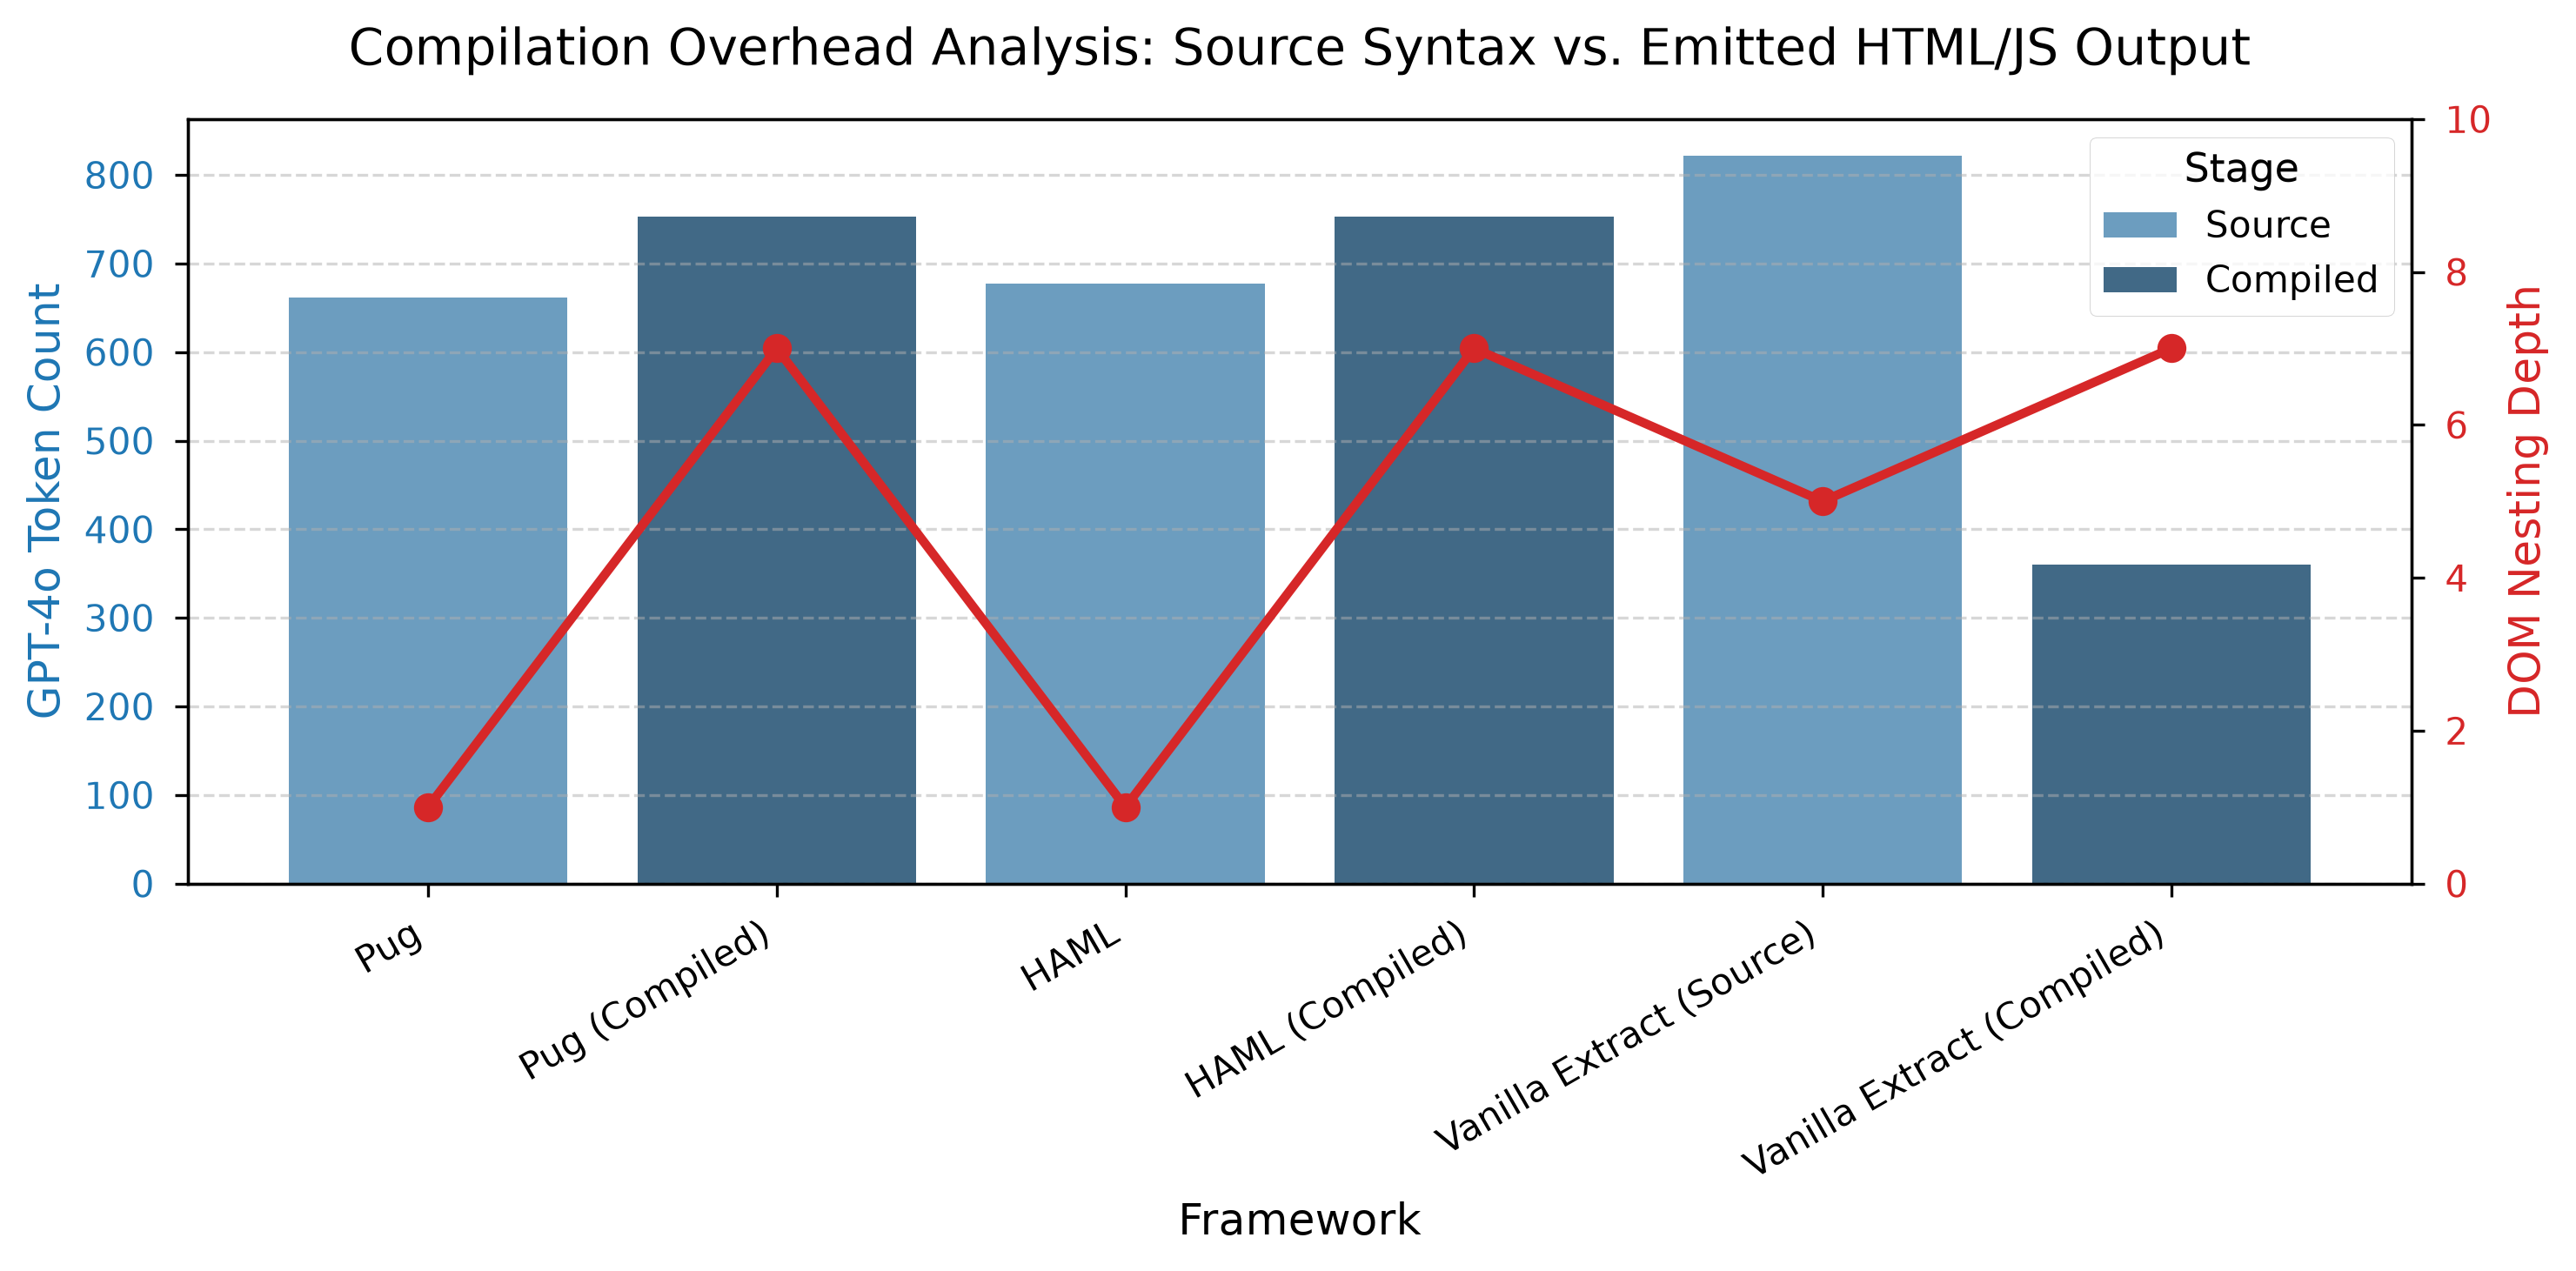

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# داده‌های مقایسه‌ای بین سورس و خروجی کامپایل‌شده (Compiled)
source_vs_compiled_data = {
    'Framework': ['Pug', 'Pug (Compiled)', 'HAML', 'HAML (Compiled)', 
                  'Vanilla Extract (Source)', 'Vanilla Extract (Compiled)'],
    'Stage': ['Source', 'Compiled', 'Source', 'Compiled', 'Source', 'Compiled'],
    'Tokens': [662, 753, 677, 753, 822, 360],
    'Nesting_Depth': [1, 7, 1, 7, 5, 7]
}

df_comp = pd.DataFrame(source_vs_compiled_data)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300)

# نمودار میله‌ای مصرف توکن
color = 'tab:blue'
sns.barplot(data=df_comp, x='Framework', y='Tokens', hue='Stage', palette='Blues_d', ax=ax1)
ax1.set_ylabel('GPT-4o Token Count', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# نمودار خطی روی محور دوم برای نشان دادن جهش عمق DOM (AST Depth)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(df_comp['Framework'], df_comp['Nesting_Depth'], color=color, marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('DOM Nesting Depth', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 10)

plt.title('Compilation Overhead Analysis: Source Syntax vs. Emitted HTML/JS Output', pad=15)
fig.tight_layout()
plt.savefig('chart6_compilation_delta.png', dpi=300)
plt.show()